# 11. 가장 센 피처가 방향을 못 맞힌다

> 2026-09-07 · 이동원 · 이슈 [#155](https://github.com/devlee328288/Alpha_Stack/issues/155) ·
> 갈라져 나온 논점: [#158](https://github.com/devlee328288/Alpha_Stack/issues/158)

오준영 님이 개별종목 모델의 피처 조합 **B~F** 를 제안하시고 다섯 가지를 확인해 달라고
하셨습니다. 의견만 드리면 부정확할 것 같아 **제안하신 피처를 전부 직접 계산해** 답합니다.

재다가 세 가지가 나왔습니다.

1. **조합 C 에는 항등식이 들어 있습니다.** `ret_1`·`overnight_gap`·`intraday_return` 은
   정의상 곱셈으로 묶여 VIF 가 2,685 입니다.
2. **단변량으로 가장 센 피처(변동성)가 방향을 못 맞힙니다.** 상승도 하락도 나란히 늘려
   "±2% 를 넘을 것인가" 만 맞힙니다.
3. **방향을 가르는 축은 단기 반전 하나**이고, 그 신호는 **변동성이 클수록 강해집니다.**
   두 축을 함께 넣어야 트리 모델이 상호작용을 잡습니다.

그리고 제가 갖고 있던 숫자 하나가 틀렸습니다 — "정지일 2.94%" 는 전 시장 값이고, 이 후보
패널에서는 **0.204%** 입니다. 영향 범위는 전 시장이 아니라 **그 코드가 실제로 도는 자리**에서
세야 합니다.

순서:

1. 후보 패널 재현 — 그리고 후보는 50개가 아니다
2. 제안된 피처를 전부 계산한다
3. 결측 — 원인별로 가른다
4. 조합 C 의 항등식
5. 방향인가 크기인가
6. 횡단면 순위로 바꾸면 무엇이 줄어드나
7. 조합마다 표본이 다르다
8. 조합 G — 방향축 × 크기축
9. 중립대 ±2% 는 맞는 크기인가 (→ #158)


In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager, rc
from scipy import stats

ROOT = Path.cwd()
while not (ROOT / "supply").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from features.indicators import (                                    # noqa: E402, I001
    bollinger_bands, macd_hist_ratio, percent_b, rsi, sma_gap)
from features.returns import n_day_return                            # noqa: E402
from features.volatility import atr, historical_volatility           # noqa: E402
from features.volume import obv, volume_ratio, volume_sma            # noqa: E402
from supply.stock_training_universe import (                         # noqa: E402
    build_sector_candidate_frame)

# HF 배포본을 내려받아 둔 자리 (2026-09-07 배포본).
OUTBOX = ROOT / "data" / "outbox" / "2026-09-07" / "full"
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

# 한글 폰트 — 수업자료(09-finance-ml-dl)와 같은 방식.
rc("font", family=font_manager.FontProperties(
    fname="C:/Windows/Fonts/malgun.ttf").get_name())
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# 라벨 색을 노트북 전체에서 고정한다 — 상승/중립/하락이 그림마다 다른 색이면 못 읽는다.
LABEL_COLOR = {"상승": "#d62728", "중립": "#adb5bd", "하락": "#1f77b4"}
t0 = time.time()
print(OUTBOX)

C:\Users\kik32\workspace\EST-Camp-AI-Quant\team_project\Alpha_Stack\data\outbox\2026-09-07\full


## 1. 후보 패널 재현 — 그리고 후보는 50개가 아니다

오준영 님 경로 그대로입니다: 반출본(개발구간) → `build_sector_candidate_frame()`.
업종 시총 상위 10개 × 업종별 보통주 상위 5개 = **날짜당 최대 50종목**입니다.

In [2]:
DAILY_COLUMNS = [
    "bas_dd", "code", "name", "market", "market_cap", "industry",
    "adj_open", "adj_high", "adj_low", "adj_close", "volume", "value",
]
daily = pd.read_parquet(OUTBOX / "daily_price_dev.parquet", columns=DAILY_COLUMNS)
daily["bas_dd"] = daily["bas_dd"].astype("string").str.zfill(8)
daily["code"] = daily["code"].astype("string").str.strip().str.zfill(6)
kospi = daily.loc[daily["market"].eq("KOSPI")].copy()
del daily
index_prices = pd.read_parquet(OUTBOX / "index_price_dev.parquet")
index_prices["bas_dd"] = index_prices["bas_dd"].astype("string").str.zfill(8)

cand = build_sector_candidate_frame(
    kospi.loc[:, ["bas_dd", "code", "name", "market", "market_cap", "industry"]],
    index_prices,
)
print(f"후보 {len(cand):,}행 · 날짜 {cand['bas_dd'].nunique():,} · 종목 {cand['code'].nunique()}"
      f" · {time.time() - t0:.0f}초")
print(f"기간 {cand['bas_dd'].min()} ~ {cand['bas_dd'].max()}")
cand.groupby("bas_dd").size().value_counts().sort_index().rename("날짜 수").to_frame()

후보 176,705행 · 날짜 3,618 · 종목 166 · 20초
기간 20100104 ~ 20240830


,날짜 수
48,1678
49,839
50,1101


**50개인 날이 1,101일뿐입니다.** 69.57% 의 날은 48~49개입니다. 왜 못 채우는지 업종별로
봅니다.

In [3]:
per_sector = cand.groupby(["bas_dd", "industry_index_name"]).size()
short = per_sector[per_sector < 5]
print(f"업종×날짜 {len(per_sector):,}개 중 5종목을 못 채운 것 {len(short):,}개")
print(short.reset_index().groupby("industry_index_name").size()
      .sort_values(ascending=False).rename("못 채운 날").to_frame().to_string())

per_sector.reset_index().groupby("industry_index_name")[0].agg(
    평균="mean", 최소="min", 최대="max", 등장일수="size").round(2).sort_values("평균").head(3)

업종×날짜 36,180개 중 5종목을 못 채운 것 2,517개
                     못 채운 날
industry_index_name        
통신                     2517


,평균,최소,최대,등장일수
industry_index_name,,,,
통신,3.34,3,5,2526
건설,5.00,5,5,716
증권,5.00,5,5,154


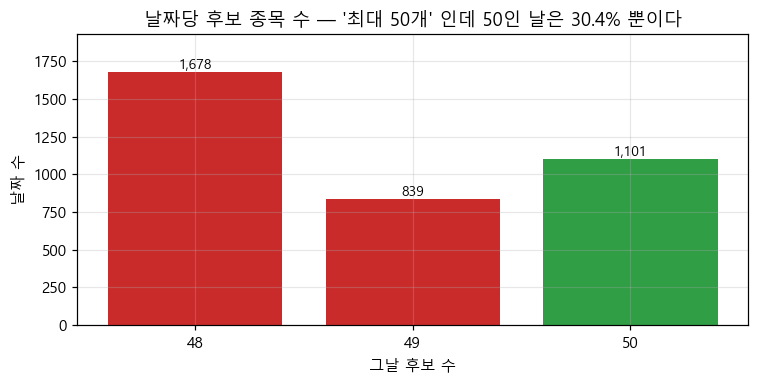

In [4]:
counts = cand.groupby("bas_dd").size().value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.bar(counts.index.astype(str), counts.to_numpy(),
              color=["#c92a2a" if i < 50 else "#2f9e44" for i in counts.index])
for b, v in zip(bars, counts.to_numpy(), strict=True):
    ax.text(b.get_x() + b.get_width() / 2, v + 20, f"{v:,}", ha="center", fontsize=9)
ax.set_title("날짜당 후보 종목 수 — '최대 50개' 인데 50인 날은 30.4% 뿐이다")
ax.set_xlabel("그날 후보 수")
ax.set_ylabel("날짜 수")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

**통신 하나입니다.** KOSPI 통신 보통주가 평균 3.34개(최소 3)뿐이라 "업종별 상위 5개" 를
채우지 못합니다. 조합 F 의 횡단면 순위는 `rank(pct=True)` 라 **분모가 날마다 46~50 으로
변합니다.**

## 2. 제안된 피처를 전부 계산한다

종목 시계열 피처는 후보를 자르기 전 **그 종목의 전체 개발 시계열**에서 계산합니다. 후보로
뽑힌 날만 이어 붙여 계산하면 편입·이탈 때마다 이동창이 끊겨 다른 값을 재게 됩니다.

In [5]:
codes = cand["code"].unique()
src = kospi.loc[kospi["code"].isin(codes)].copy()
src = src.sort_values(["code", "bas_dd"], kind="stable").reset_index(drop=True)
for col in ("adj_open", "adj_high", "adj_low", "adj_close", "volume", "value", "market_cap"):
    src[col] = pd.to_numeric(src[col], errors="coerce")

# 조합 A 의 현행 12개 — features/stock_model_dataset.py 와 같은 식으로 계산한다.
parts = []
for _, grp in src.groupby("code", sort=False):
    o = grp.sort_values("bas_dd", kind="stable").copy()
    close = o["adj_close"].to_numpy(dtype=float)
    high = o["adj_high"].to_numpy(dtype=float)
    low = o["adj_low"].to_numpy(dtype=float)
    vol = o["volume"].to_numpy(dtype=float)
    bands = bollinger_bands(close, 20)
    obv_v = obv(close, vol)
    vavg = volume_sma(vol, 20)
    with np.errstate(divide="ignore", invalid="ignore"):
        o["sma_gap_5_20"] = sma_gap(close, 5, 20)
        o["sma_gap_20_60"] = sma_gap(close, 20, 60)
        o["rsi_14"] = rsi(close, 14)
        o["macd_hist_ratio"] = macd_hist_ratio(close)
        o["bb_bandwidth"] = bands["bandwidth"]
        o["bb_position"] = percent_b(close, 20)
        o["atr_ratio"] = atr(high, low, close, 14) / close
        o["hv_20"] = historical_volatility(close, 20)
        o["vol_ratio_20"] = volume_ratio(vol, 20)
        o["obv_slope_20"] = (obv_v - pd.Series(obv_v).shift(20).to_numpy()) / (vavg * 20.0)
        o["daily_return"] = n_day_return(close, 1)
        o["five_day_return"] = n_day_return(close, 5)
    parts.append(o)
src = pd.concat(parts, ignore_index=True).replace([np.inf, -np.inf], np.nan)
print(f"조합 A 12개 완료 · {time.time() - t0:.0f}초")

조합 A 12개 완료 · 47초


In [6]:
# #155 §5 의 새 파생피처 정의 그대로.
g = src.groupby("code", sort=False)
src["seq"] = g.cumcount()                       # 종목별 상장 이후 몇 번째 행인가 (워밍업 판별)
src["ret_1"] = g["adj_close"].pct_change(1, fill_method=None)
src["ret_5"] = g["adj_close"].pct_change(5, fill_method=None)
src["ret_20"] = g["adj_close"].pct_change(20, fill_method=None)
src["dist_high_20"] = src["adj_close"] / g["adj_close"].transform(
    lambda s: s.rolling(20).max()) - 1.0
src["dist_high_60"] = src["adj_close"] / g["adj_close"].transform(
    lambda s: s.rolling(60).max()) - 1.0
src["overnight_gap"] = src["adj_open"] / g["adj_close"].shift(1) - 1.0
src["intraday_return"] = src["adj_close"] / src["adj_open"] - 1.0
src["range_1"] = (src["adj_high"] - src["adj_low"]) / src["adj_close"]
src["range_20"] = src.groupby("code", sort=False)["range_1"].transform(
    lambda s: s.rolling(20).mean())
src["close_location"] = (src["adj_close"] - src["adj_low"]) / (src["adj_high"] - src["adj_low"])
src["log_volume"] = np.log1p(src["volume"])
lv = src.groupby("code", sort=False)["log_volume"]
src["volume_z_20"] = (src["log_volume"] - lv.transform(lambda s: s.rolling(20).mean())) / (
    lv.transform(lambda s: s.rolling(20).std()))
src["turnover"] = src["value"] / src["market_cap"]
src["turnover_20"] = src.groupby("code", sort=False)["turnover"].transform(
    lambda s: s.rolling(20).mean())
EPS = 1e-20
src["_amihud"] = (src["ret_1"].abs() / src["value"]).replace([np.inf, -np.inf], np.nan)
src["_amihud_20"] = src.groupby("code", sort=False)["_amihud"].transform(
    lambda s: s.rolling(20).mean())
src["log_amihud_20"] = np.log(src["_amihud_20"] + EPS)

# 정지일·분모 0 을 원인별로 표시해 둔다. 결측을 나중에 원인으로 가르기 위해서다.
src["f_halt_ohl"] = src["adj_open"].isna() | src["adj_high"].isna() | src["adj_low"].isna()
src["f_hl_equal"] = src["adj_high"].notna() & src["adj_high"].eq(src["adj_low"])
src["f_value_nonpos"] = src["value"].isna() | src["value"].le(0)
src["f_mcap_nonpos"] = src["market_cap"].isna() | src["market_cap"].le(0)
print(f"신규 종목 피처 완료 · {time.time() - t0:.0f}초")

신규 종목 피처 완료 · 48초


In [7]:
# 업종지수·KOSPI200 — 예측일 T 종가까지만 쓴다.
idx = index_prices.loc[index_prices["index_class"].eq("KOSPI")].copy()
idx["close"] = pd.to_numeric(idx["close"], errors="coerce")
idx = idx.sort_values(["index_name", "bas_dd"], kind="stable")
ig = idx.groupby("index_name", sort=False)
idx["sector_ret_1"] = ig["close"].pct_change(1, fill_method=None)
idx["sector_ret_5"] = ig["close"].pct_change(5, fill_method=None)
idx["sector_ret_20"] = ig["close"].pct_change(20, fill_method=None)
idx["sector_hv_20"] = np.concatenate([
    historical_volatility(grp["close"].to_numpy(dtype=float), 20)
    for _, grp in idx.groupby("index_name", sort=False)])
sector_frame = idx.loc[:, ["bas_dd", "index_name", "sector_ret_1", "sector_ret_5",
                           "sector_ret_20", "sector_hv_20"]].rename(
    columns={"index_name": "industry_index_name"})
k200 = idx.loc[idx["index_name"].eq("코스피 200"), ["bas_dd", "sector_ret_5"]].rename(
    columns={"sector_ret_5": "market_ret_5"})
print(f"KOSPI200 {len(k200):,}일 · 후보 날짜 {cand['bas_dd'].nunique():,}일")

A12 = ["sma_gap_5_20", "sma_gap_20_60", "rsi_14", "macd_hist_ratio", "bb_bandwidth",
       "bb_position", "atr_ratio", "hv_20", "vol_ratio_20", "obv_slope_20",
       "daily_return", "five_day_return"]
NEW = ["seq", "ret_1", "ret_5", "ret_20", "dist_high_20", "dist_high_60",
       "overnight_gap", "intraday_return", "range_1", "range_20", "close_location",
       "volume_z_20", "turnover_20", "log_amihud_20", "_amihud_20",
       "f_halt_ohl", "f_hl_equal", "f_value_nonpos", "f_mcap_nonpos"]

panel = cand.merge(src.loc[:, ["bas_dd", "code", *A12, *NEW]],
                   on=["bas_dd", "code"], how="left", validate="one_to_one")
panel = panel.merge(sector_frame, on=["bas_dd", "industry_index_name"], how="left",
                    validate="many_to_one")
panel = panel.merge(k200, on="bas_dd", how="left", validate="many_to_one")
panel["relative_ret_5_sector"] = panel["ret_5"] - panel["sector_ret_5"]
panel["relative_ret_20_sector"] = panel["ret_20"] - panel["sector_ret_20"]
panel["relative_ret_5_market"] = panel["ret_5"] - panel["market_ret_5"]
print(f"패널 {len(panel):,}행 · {panel.shape[1]}칸")

KOSPI200 3,618일 · 후보 날짜 3,618일


패널 176,705행 · 51칸


In [8]:
# sector_beta_60 — 종목 일간수익률과 그 종목 업종지수의 60일 롤링 회귀계수.
beta = src.loc[:, ["bas_dd", "code", "ret_1"]].merge(
    cand.loc[:, ["code", "industry_index_name"]].drop_duplicates("code"), on="code", how="left")
beta = beta.merge(sector_frame.loc[:, ["bas_dd", "industry_index_name", "sector_ret_1"]],
                  on=["bas_dd", "industry_index_name"], how="left")
beta = beta.sort_values(["code", "bas_dd"], kind="stable")
betas = []
for _, d in beta.groupby("code", sort=False):
    out = d.loc[:, ["bas_dd", "code"]].copy()
    out["sector_beta_60"] = (d["ret_1"].rolling(60).cov(d["sector_ret_1"])
                             / d["sector_ret_1"].rolling(60).var()).to_numpy()
    betas.append(out)
panel = panel.merge(pd.concat(betas, ignore_index=True).replace([np.inf, -np.inf], np.nan),
                    on=["bas_dd", "code"], how="left", validate="one_to_one")

# 횡단면 순위 — 그날 후보 안에서만. rank(pct=True) 는 결측을 빼고 세므로 분모가 날마다 다르다.
dg = panel.groupby("bas_dd", sort=False)
panel["ret_5_rank"] = dg["ret_5"].rank(pct=True)
panel["sector_relative_rank"] = dg["relative_ret_5_sector"].rank(pct=True)
panel["turnover_rank"] = dg["turnover_20"].rank(pct=True)
panel["hv_20_rank"] = dg["hv_20"].rank(pct=True)
panel["market_cap_percentile"] = dg["market_cap"].rank(pct=True)
print(f"패널 완성 {len(panel):,}행 · {panel.shape[1]}칸 · {time.time() - t0:.0f}초")

패널 완성 176,705행 · 57칸 · 51초


In [9]:
# 라벨 — T+1 adj_open 진입 · T+6 adj_open 청산 · ±2% 3분류.
panel_full = panel.copy()          # 청산일·진입가로 자르기 전 후보 전체
calendar = sorted(kospi["bas_dd"].unique().tolist())
cal = pd.DataFrame({"bas_dd": calendar})
cal["entry_bas_dd"] = cal["bas_dd"].shift(-1)
cal["exit_bas_dd"] = cal["bas_dd"].shift(-6)
panel = panel.merge(cal, on="bas_dd", how="left", validate="many_to_one")
# 개발구간 마지막 6거래일은 청산일이 없다. 빈 날짜를 남긴 채 조인하면 pandas 가 여러
# NaN 을 같은 키로 세므로 먼저 비운다.
panel = panel.loc[panel["exit_bas_dd"].notna()].copy()
kospi["adj_open"] = pd.to_numeric(kospi["adj_open"], errors="coerce")
opens = kospi.loc[kospi["adj_open"].notna() & kospi["adj_open"].gt(0),
                  ["bas_dd", "code", "adj_open"]]
panel = panel.merge(opens.rename(columns={"bas_dd": "entry_bas_dd", "adj_open": "entry_open"}),
                    on=["entry_bas_dd", "code"], how="left", validate="one_to_one")
panel = panel.merge(opens.rename(columns={"bas_dd": "exit_bas_dd", "adj_open": "exit_open"}),
                    on=["exit_bas_dd", "code"], how="left", validate="one_to_one")
has_label = panel["entry_open"].notna() & panel["exit_open"].notna()
panel["fwd_return_5d"] = panel["exit_open"] / panel["entry_open"] - 1.0
up = panel["exit_open"] > panel["entry_open"] * 1.02
down = panel["exit_open"] < panel["entry_open"] * 0.98
panel["label"] = np.where(~has_label, None, np.select([up, down], ["상승", "하락"], default="중립"))
base = panel.loc[has_label].copy()
print(f"라벨 가능 {len(base):,}행 / 후보 {len(panel):,}행")
base["label"].value_counts(normalize=True).mul(100).round(2).rename("%").to_frame()

라벨 가능 175,914행 / 후보 176,405행


,%
label,
중립,37.72
하락,31.77
상승,30.50


## 3. 결측 — 원인별로 가른다

제가 이슈에 답하려던 첫 문장은 *"정지일 231,808행(2.94%)이 장중 피처를 전부 밟는다"* 였습니다.
그건 **전 시장 788만 행**의 값입니다. 이 후보 패널에서 다시 셉니다.

In [10]:
# 🔴 기준을 둘로 나눠 센다. 후보 전체와, 라벨(T+1 진입·T+6 청산가)까지 있는 행은
# 다른 표본이다. 정지일 종목은 T+1 진입가가 없어 라벨 단계에서 대부분 걸러진다.
n_full, n = len(panel_full), len(base)
print(f"후보 전체 {n_full:,}행 · 라벨 있는 행 {n:,}행")
rows = []
for f, label in [("f_halt_ohl", "정지일 (시·고·저가 결측)"),
                 ("f_hl_equal", "고가 == 저가 (close_location 분모 0)"),
                 ("f_value_nonpos", "거래대금 <= 0"),
                 ("f_mcap_nonpos", "시가총액 <= 0 (turnover 불가)")]:
    a = int(panel_full[f].fillna(False).sum())
    b_ = int(base[f].fillna(False).sum())
    rows.append({"원인": label,
                 "후보 전체": a, "후보 전체 %": round(a / n_full * 100, 3),
                 "라벨 있는 행": b_, "라벨 있는 행 %": round(b_ / n * 100, 3)})
display(pd.DataFrame(rows))

NEW_FEATURES = [
    "ret_1", "ret_5", "ret_20", "dist_high_20", "dist_high_60", "overnight_gap",
    "intraday_return", "range_1", "range_20", "close_location", "volume_z_20",
    "turnover_20", "log_amihud_20", "sector_ret_5", "sector_ret_20",
    "relative_ret_5_sector", "relative_ret_20_sector", "relative_ret_5_market",
    "sector_hv_20", "sector_beta_60", "ret_5_rank", "sector_relative_rank",
    "turnover_rank", "hv_20_rank", "market_cap_percentile",
]
rows = []
for col in NEW_FEATURES:
    v = pd.to_numeric(base[col], errors="coerce")
    m = v.isna()
    rows.append({
        "피처": col, "결측": int(m.sum()), "결측%": round(float(m.mean()) * 100, 3),
        "정지일": int((m & base["f_halt_ohl"].fillna(False)).sum()),
        "고저동일": int((m & base["f_hl_equal"].fillna(False)).sum()),
        "워밍업(seq<20)": int((m & (base["seq"] < 20)).sum()),
        "최소": None if v.notna().sum() == 0 else round(float(v.min()), 4),
        "최대": None if v.notna().sum() == 0 else round(float(v.max()), 4),
    })
pd.DataFrame(rows).sort_values("결측%", ascending=False)

후보 전체 176,705행 · 라벨 있는 행 175,914행


,원인,후보 전체,후보 전체 %,라벨 있는 행,라벨 있는 행 %
0,정지일 (시·고·저가 결측),361,0.204,28,0.016
1,고가 == 저가 (close_location 분모 0),60,0.034,49,0.028
2,거래대금 <= 0,361,0.204,28,0.016
3,시가총액 <= 0 (turnover 불가),0,0.000,0,0.000


,피처,결측,결측%,정지일,고저동일,워밍업(seq<20),최소,최대
19,sector_beta_60,3034,1.725,2,3,988,-0.7834,5.4888
4,dist_high_60,2982,1.695,2,3,988,-0.6474,0.0000
12,log_amihud_20,1502,0.854,28,23,988,-33.3244,-18.9269
8,range_20,1452,0.825,28,23,938,0.0066,0.1669
2,ret_20,988,0.562,1,0,988,-0.5692,3.2414
23,hv_20_rank,988,0.562,1,0,988,0.0200,1.0000
16,relative_ret_20_sector,988,0.562,1,0,988,-0.5386,3.1936
14,sector_ret_20,958,0.545,1,0,958,-0.4621,0.5329
18,sector_hv_20,958,0.545,1,0,958,0.0038,0.0587
10,volume_z_20,942,0.535,5,0,937,-4.1130,4.2485


**정지일이 후보 전체 361행(0.204%)에서 라벨 있는 행 28행(0.016%)으로 줄었습니다.**
정지일 종목은 T+1 진입가가 없어 라벨 단계에서 이미 걸러집니다 — 장중 피처의 결측이
학습 표본에 닿기 전에 사라집니다.

아래 피처별 결측표는 **라벨 있는 175,914행** 기준입니다. 결측 최대가 `sector_beta_60` 의 **1.73%** 이고 전부 60일 워밍업입니다. `log_amihud_20` 이
epsilon 바닥값 `log(1e-20) = −46.05` 에 붙은 행이 있는지도 봅니다 — 있으면 인공 바닥이
생겨 분포가 왜곡됩니다.

In [11]:
floor = np.log(EPS)
print(f"log_amihud_20 == log(eps) 인 행: {int(np.isclose(base['log_amihud_20'], floor).sum()):,}")
print(f"_amihud_20 == 0 인 행:          {int(base['_amihud_20'].eq(0).sum()):,}")
print(f"hv_20 == 0 (20일 무변동):        {int(base['hv_20'].eq(0).sum()):,}")
print(f"range_1 == 0 (고가==저가):       {int(base['range_1'].eq(0).sum()):,}")
base["log_amihud_20"].describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]).round(3)

log_amihud_20 == log(eps) 인 행: 0
_amihud_20 == 0 인 행:          0
hv_20 == 0 (20일 무변동):        7
range_1 == 0 (고가==저가):       49


count    174412.000
mean        -28.218
std           1.454
min         -33.324
0.1%        -32.627
1%          -31.373
50%         -28.342
99%         -23.545
99.9%       -19.976
max         -18.927
Name: log_amihud_20, dtype: float64

**바닥에 붙은 행이 없습니다.** epsilon 이 제 역할만 하고 분포를 건드리지 않았습니다.

즉 **제안하신 피처는 전부 계산됩니다.** 여기까지가 "된다/안 된다" 이고, 이제부터가
"쓸모 있나" 입니다.

## 4. 조합 C 의 항등식

`ret_1`·`overnight_gap`·`intraday_return` 은 전날 종가 → 당일 시가 → 당일 종가로 가는
같은 길을 세 조각으로 나눈 것입니다. 그래서 **정의상 곱셈으로 묶입니다.**

$$(1 + ret_1) = (1 + overnight\_gap) \times (1 + intraday\_return)$$

In [12]:
m = base[["ret_1", "overnight_gap", "intraday_return"]].dropna()
resid = (np.log1p(m["ret_1"]) - np.log1p(m["overnight_gap"]) - np.log1p(m["intraday_return"])).abs()
print(f"대상 {len(m):,}행")
print(f"로그 항등식 잔차: 최대 {resid.max():.3e} · 평균 {resid.mean():.3e}"
      f" · 1e-12 초과 {int((resid > 1e-12).sum()):,}행")
r = np.corrcoef(m["ret_1"], m["overnight_gap"] + m["intraday_return"])[0, 1]
print(f"corr(ret_1, gap + intraday) = {r:.8f}")


def vif_of(cols):
    """상관행렬 역행렬의 대각이 VIF 다. 특이행렬이면 pinv 가 유사역행렬을 준다."""
    x = base.loc[:, cols].dropna()
    inv = np.linalg.pinv(np.corrcoef(x.to_numpy().T))
    return pd.Series(np.diag(inv), index=cols)


C = ["ret_1", "ret_5", "overnight_gap", "intraday_return", "close_location",
     "bb_position", "rsi_14", "volume_z_20"]
rows = []
for drop in (None, "ret_1", "overnight_gap", "intraday_return"):
    cols = [c for c in C if c != drop] if drop else C
    v = vif_of(cols)
    rows.append({"조합 C": "원안 그대로" if drop is None else f"{drop} 제거",
                 "피처 수": len(cols), "VIF 최대": round(float(v.max()), 2),
                 "최대인 피처": v.idxmax(), "VIF 중앙": round(float(v.median()), 2)})
pd.DataFrame(rows)

대상 175,836행
로그 항등식 잔차: 최대 3.166e-16 · 평균 5.659e-17 · 1e-12 초과 0행
corr(ret_1, gap + intraday) = 0.99980857


,조합 C,피처 수,VIF 최대,최대인 피처,VIF 중앙
0,원안 그대로,8,2685.40,ret_1,5.32
1,ret_1 제거,7,5.79,bb_position,2.15
2,overnight_gap 제거,7,5.79,bb_position,4.60
3,intraday_return 제거,7,5.79,bb_position,2.15


**잔차가 부동소수점 한계(1e-16)입니다.** 수학적 항등식이 맞습니다. `ret_1` 하나만 빼면
VIF 가 2,685 → 5.79 로 떨어집니다.

다른 조합의 VIF 도 같은 자리에서 재 둡니다.

In [13]:
COMBOS = {
    "A": A12,
    "B": ["ret_5", "ret_20", "sma_gap_5_20", "sma_gap_20_60", "rsi_14",
          "dist_high_20", "dist_high_60"],
    "C": C,
    "C(ret_1 제거)": [c for c in C if c != "ret_1"],
    "D": ["atr_ratio", "hv_20", "range_1", "range_20", "bb_bandwidth",
          "volume_z_20", "turnover_20", "log_amihud_20"],
    "E": ["sector_ret_5", "sector_ret_20", "relative_ret_5_sector",
          "relative_ret_20_sector", "relative_ret_5_market", "sector_hv_20",
          "sector_beta_60"],
    "F": ["ret_5_rank", "sector_relative_rank", "turnover_rank", "hv_20_rank",
          "market_cap_percentile", "sector_market_cap_rank", "industry_stock_rank",
          "volume_z_20", "bb_position"],
}
rows = []
for name, cols in COMBOS.items():
    x = base.loc[:, cols].dropna()
    v = vif_of(cols)
    c = np.abs(np.corrcoef(x.to_numpy().T))
    np.fill_diagonal(c, 0.0)
    i, j = np.unravel_index(c.argmax(), c.shape)
    rows.append({"조합": name, "피처 수": len(cols),
                 "VIF 최대": round(float(v.max()), 2), "최대인 피처": v.idxmax(),
                 "VIF 중앙": round(float(v.median()), 2),
                 "최대 상관": round(float(c[i, j]), 3),
                 "그 쌍": f"{cols[i]} × {cols[j]}"})
pd.DataFrame(rows)

,조합,피처 수,VIF 최대,최대인 피처,VIF 중앙,최대 상관,그 쌍
0,A,12,23.66,macd_hist_ratio,5.29,0.892,rsi_14 × bb_position
1,B,7,5.54,rsi_14,4.59,0.850,ret_20 × sma_gap_5_20
2,C,8,2685.40,ret_1,5.32,0.890,bb_position × rsi_14
3,C(ret_1 제거),7,5.79,bb_position,2.15,0.890,bb_position × rsi_14
4,D,8,13.81,range_20,2.27,0.948,atr_ratio × range_20
5,E,7,6.68,relative_ret_5_market,1.35,0.848,relative_ret_5_sector × relative_ret_5_market
6,F,9,5.26,market_cap_percentile,2.80,0.801,ret_5_rank × sector_relative_rank


## 5. 방향인가 크기인가

먼저 단변량으로 어느 피처가 라벨과 관계가 센지 봅니다. 십분위 × 3분류 교차표에
**카이제곱 독립성 검정**을 걸고 효과크기를 **Cramér's V** 로 잽니다.

> 🔴 이 표로 피처를 고르면 **개발구간 전체를 본 뒤 고른 것**이 되어 다중검정입니다.
> 방향 감을 잡는 용도로만 봅니다.

In [14]:
FEATURES = [
    "ret_5", "ret_20", "dist_high_20", "dist_high_60", "rsi_14", "sma_gap_5_20",
    "sma_gap_20_60", "ret_1", "overnight_gap", "intraday_return", "close_location",
    "bb_position", "volume_z_20", "atr_ratio", "hv_20", "range_1", "range_20",
    "bb_bandwidth", "turnover_20", "log_amihud_20", "sector_ret_5", "sector_ret_20",
    "relative_ret_5_sector", "relative_ret_20_sector", "relative_ret_5_market",
    "sector_hv_20", "sector_beta_60", "ret_5_rank", "sector_relative_rank",
    "turnover_rank", "hv_20_rank", "market_cap_percentile", "sector_market_cap_rank",
    "industry_stock_rank",
]
rows = []
for col in FEATURES:
    d = base.loc[:, [col, "label", "fwd_return_5d"]].dropna()
    try:
        q = pd.qcut(d[col], 10, labels=False, duplicates="drop")
    except ValueError:
        continue
    if q.nunique() < 3:
        continue
    tab = pd.crosstab(q, d["label"])
    chi2, p, _, _ = stats.chi2_contingency(tab)
    v = np.sqrt(chi2 / (len(d) * (min(tab.shape) - 1)))
    up, dn = (d["label"] == "상승"), (d["label"] == "하락")
    lo, hi = q == q.min(), q == q.max()
    rows.append({
        "피처": col, "n": len(d), "V": round(float(v), 4), "p": f"{p:.1e}",
        "순편향_하위": round(float((up[lo].mean() - dn[lo].mean()) * 100), 2),
        "순편향_상위": round(float((up[hi].mean() - dn[hi].mean()) * 100), 2),
        "|수익|_하위": round(float(d.loc[lo, "fwd_return_5d"].abs().mean() * 100), 3),
        "|수익|_상위": round(float(d.loc[hi, "fwd_return_5d"].abs().mean() * 100), 3),
    })
uni = pd.DataFrame(rows)
uni["순편향_변화"] = (uni["순편향_상위"] - uni["순편향_하위"]).round(2)
uni["|수익|_변화"] = (uni["|수익|_상위"] - uni["|수익|_하위"]).round(3)
uni.sort_values("V", ascending=False).head(12)

,피처,n,V,p,순편향_하위,순편향_상위,|수익|_하위,|수익|_상위,순편향_변화,|수익|_변화
13,atr_ratio,175274,0.1260,0.0e+00,-3.05,0.33,2.379,6.173,3.38,3.794
16,range_20,174462,0.1173,0.0e+00,-2.75,-0.52,2.458,6.014,2.23,3.556
14,hv_20,174926,0.1109,0.0e+00,-3.30,-1.29,2.519,5.837,2.01,3.318
30,hv_20_rank,174926,0.0948,0.0e+00,-2.71,-4.94,2.668,5.346,-2.23,2.678
18,turnover_20,174977,0.0944,0.0e+00,-2.74,-3.57,2.908,5.566,-0.83,2.658
15,range_1,175886,0.0931,0.0e+00,-2.66,-0.38,2.679,5.565,2.28,2.886
17,bb_bandwidth,174977,0.0871,0.0e+00,-0.87,1.38,2.739,5.564,2.25,2.825
29,turnover_rank,174977,0.0805,0.0e+00,-2.83,-2.46,3.055,5.257,0.37,2.202
6,sma_gap_20_60,172932,0.0673,0.0e+00,8.12,-4.14,4.601,4.931,-12.26,0.330
3,dist_high_60,172932,0.0623,7.0e-274,8.25,-7.25,5.107,3.841,-15.50,-1.266


**V 상위가 전부 변동성입니다.** `atr_ratio` 0.126 · `range_20` 0.117 · `hv_20` 0.111 로
`ret_5`(0.060)의 두 배입니다.

그런데 **순편향(상승% − 하락%)** 열을 보면 변동성 피처는 하위·상위 십분위에서 거의 안
움직입니다. 상승도 하락도 같이 늘기 때문입니다. 십분위 3분류를 직접 펼쳐 봅니다.

In [15]:
def decile_table(col):
    d = base.loc[:, [col, "label", "fwd_return_5d"]].dropna()
    q = pd.qcut(d[col], 10, labels=False, duplicates="drop")
    out = []
    for tag, sel in (("하위", q == q.min()), ("상위", q == q.max())):
        dd = d.loc[sel]
        u = float((dd["label"] == "상승").mean() * 100)
        f = float((dd["label"] == "중립").mean() * 100)
        n_ = float((dd["label"] == "하락").mean() * 100)
        out.append({"피처": col, "십분위": tag, "상승%": round(u, 2), "중립%": round(f, 2),
                    "하락%": round(n_, 2), "순편향%p": round(u - n_, 2),
                    "|수익|평균%": round(float(dd["fwd_return_5d"].abs().mean() * 100), 3)})
    return out


pd.DataFrame(sum((decile_table(c) for c in
                  ["hv_20", "range_20", "atr_ratio", "dist_high_60", "ret_5", "rsi_14"]), []))

,피처,십분위,상승%,중립%,하락%,순편향%p,|수익|평균%
0,hv_20,하위,22.02,52.66,25.32,-3.30,2.519
1,hv_20,상위,36.97,24.76,38.27,-1.29,5.837
2,range_20,하위,21.87,53.52,24.62,-2.75,2.458
3,range_20,상위,37.75,23.99,38.26,-0.52,6.014
4,atr_ratio,하위,21.03,54.88,24.09,-3.05,2.379
5,atr_ratio,상위,38.56,23.20,38.24,0.33,6.173
6,dist_high_60,하위,39.81,28.62,31.57,8.25,5.107
7,dist_high_60,상위,27.51,37.73,34.76,-7.25,3.841
8,ret_5,하위,37.29,31.16,31.56,5.73,4.678
9,ret_5,상위,31.26,31.39,37.34,-6.08,4.658


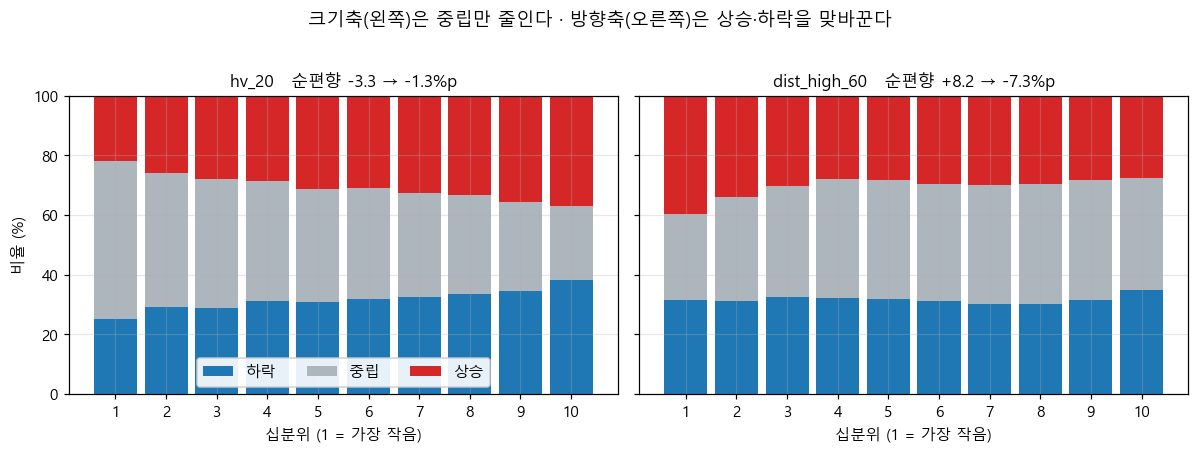

In [16]:
def decile_mix(col, ax):
    """십분위별 상승·중립·하락 비율을 누적막대로. 방향이 있으면 빨강·파랑 띠가 기울어진다."""
    d = base.loc[:, [col, "label"]].dropna()
    q = pd.qcut(d[col], 10, labels=False, duplicates="drop")
    mix = pd.crosstab(q, d["label"], normalize="index").mul(100)
    bottom = np.zeros(len(mix))
    for name in ["하락", "중립", "상승"]:
        ax.bar(mix.index + 1, mix[name], bottom=bottom, width=0.85,
               color=LABEL_COLOR[name], label=name)
        bottom += mix[name].to_numpy()
    net = mix["상승"] - mix["하락"]
    ax.set_title(f"{col}   순편향 {net.iloc[0]:+.1f} → {net.iloc[-1]:+.1f}%p", fontsize=11)
    ax.set_xlabel("십분위 (1 = 가장 작음)")
    ax.set_ylim(0, 100)
    ax.set_xticks(range(1, 11))


fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
decile_mix("hv_20", axes[0])
decile_mix("dist_high_60", axes[1])
axes[0].set_ylabel("비율 (%)")
axes[0].legend(loc="lower center", ncol=3, framealpha=0.9)
fig.suptitle("크기축(왼쪽)은 중립만 줄인다 · 방향축(오른쪽)은 상승·하락을 맞바꾼다", y=1.02)
plt.tight_layout()
plt.show()

**갈립니다.**

- `hv_20` 하위 → 상위: 상승 22.02 → 36.97(+14.95%p), 하락 25.32 → 38.27(+12.95%p).
  **둘 다 늘어** 순편향은 −3.30 → −1.29 로 그대로입니다. `|수익|` 은 2.5% → 5.8% 로 두 배.
- `dist_high_60` 하위 → 상위: 순편향 **+8.25 → −7.25**. 방향이 뒤집힙니다.

변동성은 **"±2% 를 넘을 것인가"** 를 맞히고, 신고가 거리는 **"위로 넘을까 아래로 넘을까"** 를
맞힙니다. 조합 D 만으로는 하락 Recall 이 오르지 않습니다.

In [17]:
judge = uni.set_index("피처").loc[
    ["atr_ratio", "range_20", "hv_20", "bb_bandwidth", "turnover_20", "volume_z_20",
     "dist_high_60", "sma_gap_20_60", "ret_20", "rsi_14", "ret_5", "dist_high_20",
     "relative_ret_5_market", "relative_ret_5_sector"],
    ["V", "순편향_변화", "|수익|_변화"]].copy()
judge["판정"] = np.where(judge["순편향_변화"].abs() >= 5.0, "방향축",
                       np.where(judge["|수익|_변화"].abs() > 0.5, "크기축", "약함"))
judge.sort_values("순편향_변화")

,V,순편향_변화,|수익|_변화,판정
피처,,,,
dist_high_60,0.0623,-15.50,-1.266,방향축
sma_gap_20_60,0.0673,-12.26,0.330,방향축
ret_20,0.0616,-12.03,0.000,방향축
rsi_14,0.0324,-11.90,0.041,방향축
ret_5,0.0603,-11.81,-0.020,방향축
dist_high_20,0.0543,-11.06,-1.266,방향축
relative_ret_5_market,0.0528,-10.61,0.294,방향축
relative_ret_5_sector,0.0478,-6.72,0.341,방향축
turnover_20,0.0944,-0.83,2.658,크기축


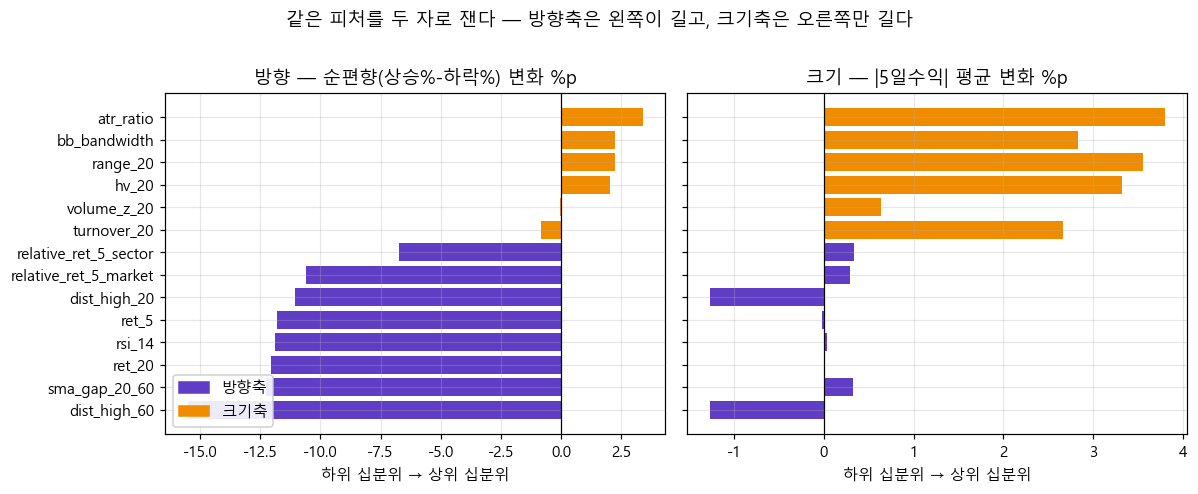

In [18]:
j = judge.sort_values("순편향_변화")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
colors = ["#5f3dc4" if t == "방향축" else "#f08c00" if t == "크기축" else "#adb5bd"
          for t in j["판정"]]
axes[0].barh(j.index, j["순편향_변화"], color=colors)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("방향 — 순편향(상승%-하락%) 변화 %p")
axes[1].barh(j.index, j["|수익|_변화"], color=colors)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("크기 — |5일수익| 평균 변화 %p")
for ax in axes:
    ax.set_xlabel("하위 십분위 → 상위 십분위")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ["#5f3dc4", "#f08c00"]]
axes[0].legend(handles, ["방향축", "크기축"], loc="lower left", framealpha=0.9)
fig.suptitle("같은 피처를 두 자로 잰다 — 방향축은 왼쪽이 길고, 크기축은 오른쪽만 길다", y=1.01)
plt.tight_layout()
plt.show()

**방향축은 전부 음수입니다** — 최근 강했던 종목이 다음 5거래일에 약합니다. 조합 B 의
가설은 *"추세 지속"* 인데 5거래일 지평에서는 **반전**이 나옵니다.

문헌과 어긋나지 않습니다. Jegadeesh-Titman(1993)의 모멘텀은 **3~12개월**이고, 1개월 이하
단기는 반전이 정설입니다(Jegadeesh 1990). **인용한 논문의 지평과 우리 라벨의 지평이
다릅니다.**

## 6. 횡단면 순위로 바꾸면 무엇이 줄어드나

조합 F 는 같은 정보를 날짜별 백분위로 바꿉니다. 원값과 순위를 나란히 놓습니다.

In [19]:
PAIRS = [("ret_5", "ret_5_rank"), ("relative_ret_5_sector", "sector_relative_rank"),
         ("hv_20", "hv_20_rank"), ("turnover_20", "turnover_rank")]
u = uni.set_index("피처")
rows = []
for raw, rank in PAIRS:
    rows.append({
        "원값": raw, "순위": rank,
        "V(원값)": u.loc[raw, "V"], "V(순위)": u.loc[rank, "V"],
        "순편향변화(원값)": u.loc[raw, "순편향_변화"],
        "순편향변화(순위)": u.loc[rank, "순편향_변화"],
    })
pd.DataFrame(rows)

,원값,순위,V(원값),V(순위),순편향변화(원값),순편향변화(순위)
0,ret_5,ret_5_rank,0.0603,0.0404,-11.81,-7.81
1,relative_ret_5_sector,sector_relative_rank,0.0478,0.0382,-6.72,-5.16
2,hv_20,hv_20_rank,0.1109,0.0948,2.01,-2.23
3,turnover_20,turnover_rank,0.0944,0.0805,-0.83,0.37


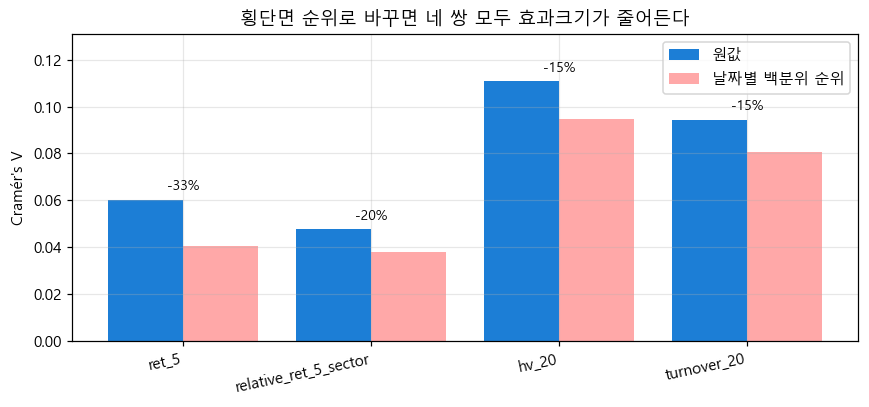

In [20]:
pairs = pd.DataFrame(rows)
x = np.arange(len(pairs))
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(x - 0.2, pairs["V(원값)"], width=0.4, label="원값", color="#1c7ed6")
ax.bar(x + 0.2, pairs["V(순위)"], width=0.4, label="날짜별 백분위 순위", color="#ffa8a8")
for i, (a, b_) in enumerate(zip(pairs["V(원값)"], pairs["V(순위)"], strict=True)):
    ax.text(i, max(a, b_) + 0.004, f"-{(a - b_) / a * 100:.0f}%", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(pairs["원값"], rotation=12, ha="right")
ax.set_ylim(0, pairs["V(원값)"].max() * 1.18)   # 막대 위 라벨이 잘리지 않게
ax.set_ylabel("Cramér's V")
ax.set_title("횡단면 순위로 바꾸면 네 쌍 모두 효과크기가 줄어든다")
ax.legend()
plt.tight_layout()
plt.show()

**네 쌍 모두 순위 쪽 V 가 낮습니다.**

*"대부분 종목이 +8%인 날의 +3%"* 라는 문제의식은 맞습니다. 다만 우리 후보는 **이미 업종
시총 상위로 좁혀진 46~50종목**이라 날짜 안 분산이 작고, 순위화가 지우는 **날짜 간** 정보가
남는 정보보다 큽니다. `hv_20` 이 그 극단입니다 — 예측력의 대부분이 "어느 날인가" 였습니다.

## 7. 조합마다 표본이 다르다

조합별로 "피처 하나라도 결측이면 행 삭제" 를 적용하면 남는 행이 달라집니다. 워밍업 창
길이가 조합마다 다르기 때문입니다.

In [21]:
masks, rows = {}, []
for name, cols in COMBOS.items():
    if name == "C(ret_1 제거)":
        continue
    ok = np.isfinite(base.loc[:, cols].to_numpy(dtype=float)).all(axis=1)
    masks[name] = ok
    d = base.loc[ok, "bas_dd"]
    rows.append({"조합": name, "유효행": int(ok.sum()), "비율%": round(float(ok.mean()) * 100, 3),
                 "날짜": int(d.nunique()), "첫날": d.min(), "버려짐": int((~ok).sum())})
inter = np.logical_and.reduce(list(masks.values()))
union = np.logical_or.reduce(list(masks.values()))
rows.append({"조합": "6개 공통", "유효행": int(inter.sum()),
             "비율%": round(float(inter.mean()) * 100, 3),
             "날짜": int(base.loc[inter, "bas_dd"].nunique()),
             "첫날": base.loc[inter, "bas_dd"].min(), "버려짐": int((~inter).sum())})
print(f"합집합 {int(union.sum()):,}행 · 공통 {int(inter.sum()):,}행"
      f" · 차이 {int(union.sum() - inter.sum()):,}행")
pd.DataFrame(rows)

합집합 174,976행 · 공통 172,379행 · 차이 2,597행


,조합,유효행,비율%,날짜,첫날,버려짐
0,A,172924,98.300,3553,20100330,2990
1,B,172932,98.305,3553,20100330,2982
2,C,174900,99.424,3593,20100129,1014
3,D,174412,99.146,3592,20100201,1502
4,E,172880,98.275,3552,20100331,3034
5,F,174918,99.434,3592,20100201,996
6,6개 공통,172379,97.990,3552,20100331,3535


날짜를 맞춰도 **같은 날짜 안에서 남는 종목이 다릅니다.** 조합 비교는 **공통 172,379행**
으로 고정해야 공정합니다. 비용은 조합당 −0.3 ~ −1.5% 입니다.

## 8. 조합 G — 방향축 × 크기축

두 축이 갈렸으니, 서로 독립인지 보고 함께 넣을 근거를 확인합니다.

In [22]:
DIRECTION = ["dist_high_60", "dist_high_20", "ret_20", "ret_5", "rsi_14", "bb_position",
             "relative_ret_5_market", "relative_ret_5_sector", "sma_gap_5_20", "sma_gap_20_60"]
SIZE = ["hv_20", "atr_ratio", "range_20", "bb_bandwidth", "turnover_20",
        "log_amihud_20", "volume_z_20"]
cross = base.loc[:, DIRECTION + SIZE].dropna().corr().loc[DIRECTION, SIZE]
print(f"방향축 × 크기축 교차상관: 절댓값 평균 {cross.abs().to_numpy().mean():.3f}"
      f" · 최대 {cross.abs().to_numpy().max():.3f}")
cross.round(3)

방향축 × 크기축 교차상관: 절댓값 평균 0.124 · 최대 0.489


,hv_20,atr_ratio,range_20,bb_bandwidth,turnover_20,log_amihud_20,volume_z_20
dist_high_60,-0.301,-0.435,-0.267,-0.262,-0.118,-0.040,0.039
dist_high_20,-0.347,-0.489,-0.326,-0.422,-0.173,-0.000,0.021
ret_20,0.188,0.024,0.214,0.261,0.293,-0.022,0.037
ret_5,0.106,-0.049,0.090,0.130,0.099,0.013,0.080
rsi_14,0.083,-0.057,0.108,0.097,0.104,-0.028,0.050
bb_position,0.069,-0.071,0.068,0.072,0.054,-0.002,0.075
relative_ret_5_market,0.099,-0.024,0.090,0.148,0.099,0.015,0.101
relative_ret_5_sector,0.095,-0.015,0.085,0.140,0.102,0.014,0.084
sma_gap_5_20,0.121,-0.042,0.133,0.180,0.181,-0.009,0.033
sma_gap_20_60,0.136,0.114,0.235,0.142,0.319,-0.083,-0.019


In [23]:
# 방향축 × 크기축 5×5 — 순편향(상승% − 하락%)
d = base.loc[:, ["dist_high_60", "hv_20", "label", "fwd_return_5d"]].dropna()
dq = pd.qcut(d["dist_high_60"], 5, labels=[f"방향{i}" for i in range(1, 6)])
sq = pd.qcut(d["hv_20"], 5, labels=[f"크기{i}" for i in range(1, 6)])
up, dn = (d["label"] == "상승"), (d["label"] == "하락")
net = (pd.crosstab(dq, sq, values=up, aggfunc="mean")
       - pd.crosstab(dq, sq, values=dn, aggfunc="mean")) * 100
print("순편향(상승% − 하락%) — 방향1 = 신고가에서 가장 멂, 방향5 = 신고가 근처")
net.round(2)

순편향(상승% − 하락%) — 방향1 = 신고가에서 가장 멂, 방향5 = 신고가 근처


hv_20,크기1,크기2,크기3,크기4,크기5
dist_high_60,,,,,
방향1,2.29,0.57,5.23,7.81,6.57
방향2,-5.31,-1.96,-1.91,-4.21,-2.33
방향3,-4.69,-1.14,-2.46,-1.51,-3.88
방향4,-0.33,-0.01,0.07,-0.16,-2.82
방향5,-6.27,-5.78,-2.81,-3.91,-8.90


In [24]:
# 방향 신호가 변동성에 따라 증폭되는가
rows = []
for dcol in ["dist_high_60", "relative_ret_5_market", "rsi_14"]:
    dd = base.loc[:, [dcol, "hv_20", "label"]].dropna()
    a = pd.qcut(dd[dcol], 5, labels=False)
    b = pd.qcut(dd["hv_20"], 5, labels=False)
    u, n_ = (dd["label"] == "상승"), (dd["label"] == "하락")
    t = (pd.crosstab(a, b, values=u, aggfunc="mean")
         - pd.crosstab(a, b, values=n_, aggfunc="mean")) * 100
    rows.append({"방향축 피처": dcol,
                 "저변동성 구간 순편향 폭": round(float(t.iloc[-1, 0] - t.iloc[0, 0]), 2),
                 "고변동성 구간 순편향 폭": round(float(t.iloc[-1, -1] - t.iloc[0, -1]), 2)})
amp = pd.DataFrame(rows)
amp["증폭"] = (amp["고변동성 구간 순편향 폭"].abs() - amp["저변동성 구간 순편향 폭"].abs()).round(2)
amp

,방향축 피처,저변동성 구간 순편향 폭,고변동성 구간 순편향 폭,증폭
0,dist_high_60,-8.56,-15.47,6.91
1,relative_ret_5_market,-11.33,-12.98,1.65
2,rsi_14,-4.40,-16.57,12.17


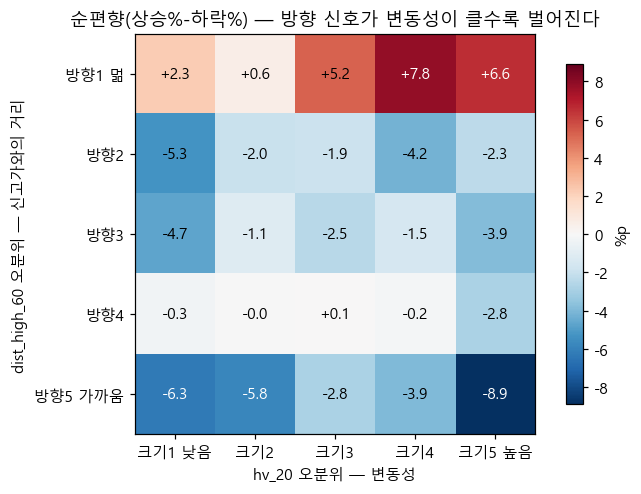

In [25]:
fig, ax = plt.subplots(figsize=(6.6, 4.6))
v = net.to_numpy(dtype=float)
lim = np.abs(v).max()
im = ax.imshow(v, cmap="RdBu_r", vmin=-lim, vmax=lim)
for i in range(v.shape[0]):
    for j_ in range(v.shape[1]):
        ax.text(j_, i, f"{v[i, j_]:+.1f}", ha="center", va="center", fontsize=10,
                color="white" if abs(v[i, j_]) > lim * 0.6 else "black")
ax.set_xticks(range(v.shape[1]), ["크기1 낮음", "크기2", "크기3", "크기4", "크기5 높음"])
ax.set_yticks(range(v.shape[0]), ["방향1 멂", "방향2", "방향3", "방향4", "방향5 가까움"])
ax.set_xlabel("hv_20 오분위 — 변동성")
ax.set_ylabel("dist_high_60 오분위 — 신고가와의 거리")
ax.set_title("순편향(상승%-하락%) — 방향 신호가 변동성이 클수록 벌어진다")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.85, label="%p")
plt.tight_layout()
plt.show()

**방향 신호가 변동성이 클수록 강해집니다.** `rsi_14` 는 저변동성 구간에서 거의 무력
(−4.40)하다가 고변동성 구간에서 −16.57 이 됩니다.

**선형 모델은 이 상호작용을 못 잡습니다.** 크기축 피처를 버릴 것이 아니라 방향축과 함께
넣어야 트리 모델이 "언제 방향 신호를 믿을지" 를 배웁니다. 조합 G 후보를 잽니다.

In [26]:
G = {
    "G-a  방향3 + 크기2": ["dist_high_60", "relative_ret_5_market", "rsi_14",
                        "hv_20", "turnover_20"],
    "G-c  + 업종상대": ["dist_high_60", "relative_ret_5_market", "relative_ret_5_sector",
                    "rsi_14", "hv_20", "turnover_20"],
    "G-d  + 장기추세": ["dist_high_60", "sma_gap_20_60", "relative_ret_5_market",
                    "rsi_14", "hv_20", "turnover_20"],
    "참고: A (현행 12)": A12,
    "참고: E (원안)": COMBOS["E"],
}
rows = []
for name, cols in G.items():
    x = base.loc[:, cols].dropna()
    v = vif_of(cols)
    c = np.abs(np.corrcoef(x.to_numpy().T))
    np.fill_diagonal(c, 0.0)
    i, j = np.unravel_index(c.argmax(), c.shape)
    rows.append({"조합": name, "피처 수": len(cols), "유효행": len(x),
                 "VIF 최대": round(float(v.max()), 2), "VIF 중앙": round(float(v.median()), 2),
                 "최대 상관": round(float(c[i, j]), 3), "그 쌍": f"{cols[i]} × {cols[j]}"})
pd.DataFrame(rows)

,조합,피처 수,유효행,VIF 최대,VIF 중앙,최대 상관,그 쌍
0,G-a 방향3 + 크기2,5,172932,3.28,1.93,0.714,dist_high_60 × rsi_14
1,G-c + 업종상대,6,172932,4.14,3.06,0.848,relative_ret_5_sector × relative_ret_5_market
2,G-d + 장기추세,6,172932,4.70,2.35,0.714,dist_high_60 × rsi_14
3,참고: A (현행 12),12,172924,23.66,5.29,0.892,rsi_14 × bb_position
4,참고: E (원안),7,172880,6.68,1.35,0.848,relative_ret_5_sector × relative_ret_5_market


`ret_5` 와 `relative_ret_5_market` 은 상관 **0.887** 이라 둘 중 하나만 넣어야 합니다.
`G-d` 가 피처 6개로 조합 A(12개)보다 VIF 가 훨씬 낮습니다.

> 🔴 이 조합은 **개발구간 전체 단변량에서 나왔습니다.** 그대로 성능을 보고하면 부풀려집니다.
> 조합 선택을 각 외부 폴드의 학습구간 안으로 넣거나(nested walk-forward), 최종 숫자는
> 봉인 홀드아웃에서 한 번만 내야 합니다.

## 9. 중립대 ±2% 는 맞는 크기인가

제 첫 감은 *"±2% 는 중립이 넓다"* 였습니다. ADR-AS-0002 는 KOSPI200 지수에 **±1.0%** 를
정했으니, 개별종목이 지수보다 얼마나 더 흔들리는지 같은 규칙으로 재서 견줍니다.

In [27]:
k = index_prices.loc[index_prices["index_name"].eq("코스피 200")
                     & index_prices["index_class"].eq("KOSPI")].copy()
k = k.sort_values("bas_dd")
k["open"] = pd.to_numeric(k["open"], errors="coerce")
k["fwd"] = k["open"].shift(-6) / k["open"].shift(-1) - 1.0   # 지수 트랙과 같은 T+1 → T+6
kf = k["fwd"].dropna()
sf = base["fwd_return_5d"].dropna()
for name, v in (("KOSPI200", kf), ("개별종목", sf)):
    print(f"{name} 5일 수익률  표준편차 {v.std() * 100:.3f}%"
          f" · 평균절대 {v.abs().mean() * 100:.3f}% · n={len(v):,}")
print(f"비율: 표준편차 {sf.std() / kf.std():.3f}배"
      f" · 평균절대 {sf.abs().mean() / kf.abs().mean():.3f}배")
print(f"→ 지수 ±1.0% 를 비례하면 개별종목은 ±{sf.std() / kf.std():.2f}%")

rows = []
for band in (0.015, 0.0175, 0.02, 0.022, 0.025):
    u = float((sf > band).mean() * 100)
    n_ = float((sf.abs() <= band).mean() * 100)
    dn_ = float((sf < -band).mean() * 100)
    rows.append({"밴드": f"±{band * 100:.2f}%", "상승%": round(u, 2), "중립%": round(n_, 2),
                 "하락%": round(dn_, 2), "최빈(기준선)%": round(max(u, n_, dn_), 2),
                 "최대−최소": round(max(u, n_, dn_) - min(u, n_, dn_), 2)})
pd.DataFrame(rows)

KOSPI200 5일 수익률  표준편차 2.404% · 평균절대 1.761% · n=3,612
개별종목 5일 수익률  표준편차 5.277% · 평균절대 3.742% · n=175,914
비율: 표준편차 2.195배 · 평균절대 2.124배
→ 지수 ±1.0% 를 비례하면 개별종목은 ±2.20%


,밴드,상승%,중립%,하락%,최빈(기준선)%,최대−최소
0,±1.50%,34.56,29.09,36.34,36.34,7.25
1,±1.75%,32.49,33.43,34.08,34.08,1.59
2,±2.00%,30.54,37.65,31.81,37.65,7.12
3,±2.20%,28.96,40.96,30.08,40.96,12.00
4,±2.50%,26.78,45.62,27.60,45.62,18.85


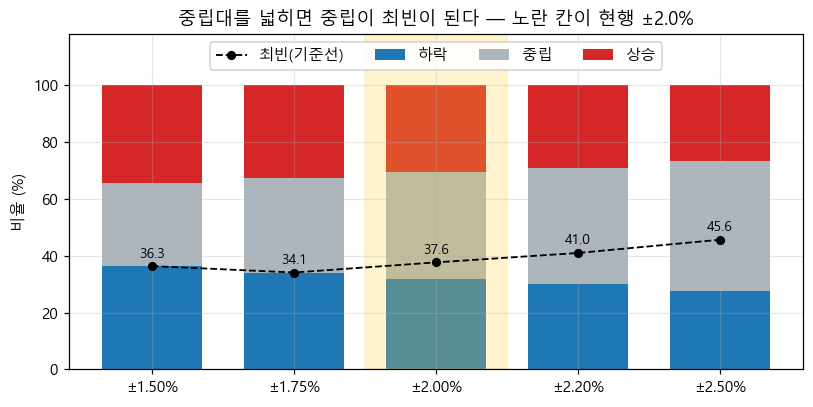

In [28]:
bands = pd.DataFrame(rows).set_index("밴드")
fig, ax = plt.subplots(figsize=(7.5, 3.8))
bottom = np.zeros(len(bands))
for name in ["하락%", "중립%", "상승%"]:
    ax.bar(bands.index, bands[name], bottom=bottom, width=0.7,
           color=LABEL_COLOR[name[:2]], label=name[:2])
    bottom += bands[name].to_numpy()
ax.plot(bands.index, bands["최빈(기준선)%"], "ko--", lw=1.2, ms=5, label="최빈(기준선)")
for i, v in enumerate(bands["최빈(기준선)%"]):
    ax.text(i, v + 3, f"{v:.1f}", ha="center", fontsize=9)
ax.axvspan(1.5, 2.5, color="#ffd43b", alpha=0.25)   # 현행 ±2.0%
ax.set_ylim(0, 118)
ax.set_ylabel("비율 (%)")
ax.set_title("중립대를 넓히면 중립이 최빈이 된다 — 노란 칸이 현행 ±2.0%")
ax.legend(ncol=4, loc="upper center", framealpha=0.9)
plt.tight_layout()
plt.show()

**제가 틀렸습니다.** 개별종목이 지수의 **2.195배**로 흔들리니 ±1.0% × 2.195 = **±2.20%**,
오준영 님 ±2.0% 는 원칙적으로 일관됩니다.

다만 **클래스 균형만 보면 ±1.75%** 가 가장 고릅니다(최대−최소 1.59%p). 근거가 서로 다른
답을 주므로 팀이 정할 문제라 보고 [#158](https://github.com/devlee328288/Alpha_Stack/issues/158)
로 분리했습니다. 연도별 기준선도 함께 둡니다.

In [29]:
base["year"] = base["bas_dd"].str[:4]
yr = pd.crosstab(base["year"], base["label"], normalize="index").mul(100).round(2)
yr["최빈"] = yr.max(axis=1).round(2)
yr["최빈클래스"] = yr[["상승", "중립", "하락"]].idxmax(axis=1)
print(f"최빈 기준선 범위 {yr['최빈'].min():.2f}% ~ {yr['최빈'].max():.2f}%"
      f" (폭 {yr['최빈'].max() - yr['최빈'].min():.2f}%p)")
yr

최빈 기준선 범위 35.62% ~ 45.22% (폭 9.60%p)


label,상승,중립,하락,최빈,최빈클래스
year,,,,,
2010,34.66,36.52,28.82,36.52,중립
2011,34.07,28.07,37.86,37.86,하락
2012,32.13,37.03,30.84,37.03,중립
2013,28.73,41.74,29.54,41.74,중립
2014,26.50,44.00,29.49,44.00,중립
2015,31.49,35.62,32.89,35.62,중립
2016,28.25,41.55,30.20,41.55,중립
2017,30.59,43.42,25.99,43.42,중립
2018,28.59,36.74,34.67,36.74,중립


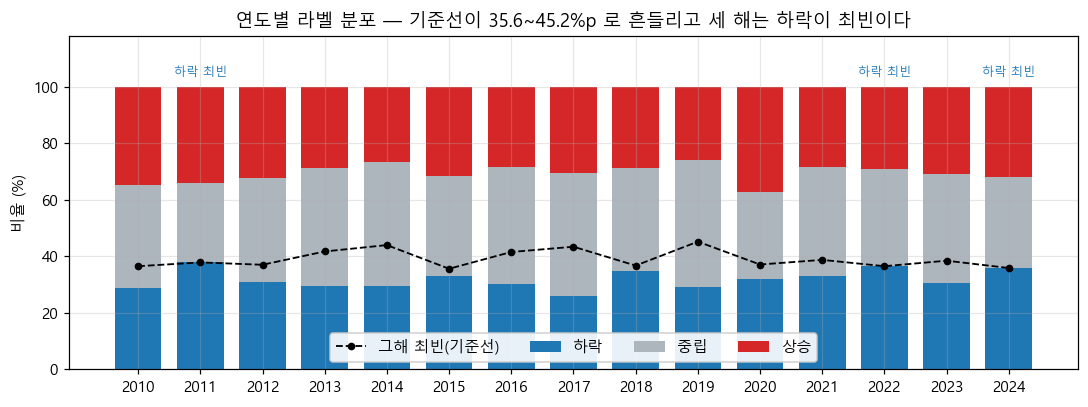

In [30]:
fig, ax = plt.subplots(figsize=(10, 3.8))
bottom = np.zeros(len(yr))
for name in ["하락", "중립", "상승"]:
    ax.bar(yr.index, yr[name], bottom=bottom, width=0.75,
           color=LABEL_COLOR[name], label=name)
    bottom += yr[name].to_numpy()
ax.plot(yr.index, yr["최빈"], "ko--", lw=1.2, ms=4, label="그해 최빈(기준선)")
for i in range(len(yr)):
    if yr["최빈클래스"].iloc[i] == "하락":
        ax.text(i, 104, "하락 최빈", ha="center", fontsize=8, color="#1f77b4")
ax.set_ylim(0, 118)
ax.set_ylabel("비율 (%)")
ax.set_title("연도별 라벨 분포 — 기준선이 35.6~45.2%p 로 흔들리고 세 해는 하락이 최빈이다")
ax.legend(ncol=4, loc="lower center", framealpha=0.9)
plt.tight_layout()
plt.show()

In [31]:
# 랭킹 지표의 기준선 — Top-K 적중률이 무엇을 넘어야 의미가 있나
p_up = float((base["label"] == "상승").mean())
avg = base.groupby("bas_dd")["fwd_return_5d"].mean().mean()
mkt = base.groupby("bas_dd")["market_ret_5"].first().mean()
best5 = base.groupby("bas_dd")["fwd_return_5d"].apply(lambda s: s.nlargest(5).mean()).mean()
worst5 = base.groupby("bas_dd")["fwd_return_5d"].apply(lambda s: s.nsmallest(5).mean()).mean()
pd.DataFrame([
    {"기준": "후보를 무작위로 골랐을 때 상승 확률", "값": f"{p_up * 100:.2f}%"},
    {"기준": "후보 전체 평균 5일 수익률 (날짜평균)", "값": f"{avg * 100:+.4f}%"},
    {"기준": "같은 기간 KOSPI200 5일 수익률", "값": f"{mkt * 100:+.4f}%"},
    {"기준": "[상한] 매일 실제 상위 5종목", "값": f"{best5 * 100:+.3f}%"},
    {"기준": "[하한] 매일 실제 하위 5종목", "값": f"{worst5 * 100:+.3f}%"},
])

,기준,값
0,후보를 무작위로 골랐을 때 상승 확률,30.50%
1,후보 전체 평균 5일 수익률 (날짜평균),+0.0654%
2,같은 기간 KOSPI200 5일 수익률,+0.1001%
3,[상한] 매일 실제 상위 5종목,+8.356%
4,[하한] 매일 실제 하위 5종목,-7.086%


🔴 **후보 50종목의 평균 수익률이 KOSPI200 보다 낮습니다.** 업종 시총 상위로 후보를 좁힌
것 자체는 알파를 주지 않습니다. 랭킹이 그 안에서 골라야 시장을 이깁니다. 상한 +8.36%/5일은
고를 여지가 충분하다는 뜻입니다.

---

## 정리

| 물어보신 것 | 답 |
|---|---|
| 조합 A 기준선 유지 + B~F 추가 | 네. 다만 A 는 VIF 최대 23.66 이라 기준선으로만 |
| 조합 E 우선 구현 | 네. VIF 중앙 1.35 로 가장 건강 |
| 조합 F 를 후보 최대 50개로 | 계산은 됨. 다만 후보는 46~50개이고 순위화로 V 가 준다 |
| 선정 기준 유지 | 피처 비교에는 유지. 폴드별 기준선을 함께 (#158) |
| #132 뒤 A~F 재실행 순서 | 맞음. `attach_adjustment_quality` 는 이미 main 에 있음 |

**추가로 드린 것**

1. 조합 C 에서 `ret_1` 을 뺀다 — VIF 2,685 → 5.79
2. 조합 B 의 가설 문장을 뒤집는다 — 5거래일 지평은 반전이다
3. 조합 D 는 단독으로 하락 Recall 을 못 올린다 — 크기축이다
4. 조합 비교는 공통 172,379행으로 고정한다
5. 조합 G(방향축 × 크기축)를 제안한다 — 다만 다중검정을 조심한다

**제가 배운 것**

영향 범위는 **그 코드가 실제로 도는 자리**에서 세야 합니다. 전 시장 2.94% 를 그대로 답했으면
0.204% 인 자리에 경고를 붙일 뻔했습니다. 그리고 **V 가 가장 큰 피처가 방향을 못 맞혔습니다** —
효과크기 하나로 줄을 세우면 "무엇을 맞히는 효과인가" 를 놓칩니다.